##**Text generation Experiment**

- 이번 복습과제에는 GPT-2 모델을 사용한 텍스트 생생을 다룹니다. 🙂
- GPT-2는 약 40GB의 인터넷 텍스트 데이터로 훈련된 모델로 다음 단어 예측(next word prediction)을 목적으로 학습이 되었습니다
- Beam Search, Top-k sampling, Top-p sampling 과 같은 다양한 디코딩 기법들을 실험해보겠습니다.

In [ ]:
#reproducability을 위해 해당 코드를 실행해주세요
SEED = 34
#max number of words in output text
MAX_LEN = 70

In [ ]:
# 실험할 문장입니다.
input_sequence = "I don't know about you, but there's only one thing I want to do after a long day of work"

In [ ]:
# transformers을 가져와서 사용해봅시다
from transformers import TFGPT2LMHeadModel, GPT2Tokenizer

# pretrained large GPT2 tokenizer 와  GPT2 model를 가져와주세요.
tokenizer = GPT2Tokenizer.from_pretrained("gpt2-large")
GPT2 = TFGPT2LMHeadModel.from_pretrained("gpt2-large", pad_token_id=tokenizer.eos_token_id)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFGPT2LMHeadModel.

All the weights of TFGPT2LMHeadModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2LMHeadModel for predictions without further training.


In [ ]:
# model parameters을 확인해 봅시다.
GPT2.summary()

Model: "tfgpt2lm_head_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 transformer (TFGPT2MainLay  multiple                  774030080 
 er)                                                             
                                                                 
Total params: 774030080 (2.88 GB)
Trainable params: 774030080 (2.88 GB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
#아래 코드를 실행해주세요-
import tensorflow as tf
tf.random.set_seed(SEED)

### **Greedy-Search**
- Greedy Search 에서는 각 시점마다 가장 확률이 높은 단어를 다음 단어로 선택합니다.
- 즉, 다음 단어는 아래와 같이 업데이트됩니다:

$ wt=argmax wP(w|w1:t−1) $  

> 즉, 각 타임스텝 𝑡마다 조건부 확률이 가장 높은 단어를 선택하는 것!


- 이 단순한 접근방식이 어떤 성능 차이를 보이는지 살펴봅시다.

In [ ]:
# context를 encoder해주세요
input_ids = tokenizer.encode(input_sequence, return_tensors="tf")

# 텍스트 생성하기, 이때 output length가 (context length 포함) 50이 될 때까지
greedy_output = GPT2.generate(
    input_ids=input_ids,
    max_length=50,
    do_sample=False
)

# output sequences 출력하기
print("Output:\n" + 100 * '-')
print(tokenizer.decode(greedy_output[0], skip_special_tokens = True))

Output:
----------------------------------------------------------------------------------------------------
I don't know about you, but there's only one thing I want to do after a long day of work: go to the gym.

I'm not talking about the gym that's right next to my house. I'm talking about


💡**위 Greedy Search 식과 코드 결과를 보고 고려되는 주요 문제점을 해당 셀을 풀고 설명해주세요.**


---


- 각 시점에서 가장 확률이 높은 단어만을 선택하기 때문에 do_sample=False로 설정했기 때문에 확률 기반 샘플링 없이 가장 높은 확률 단어 선택
- 모델이 높은 활률의 평범한 단어를 선택하기 대문에 출력 문장이 단순하다.

### **Beam Search + N-Gram Penalty**
- Beam Search는 기본적으로 Greedy Search와 유사하지만, 모델이 각 시점에서 여러 개(num_beams)의 후보 경로를 동시에 추적한다는 점이 다릅니다
 > 즉, 모델이 여러 대안을 비교하면서 텍스트를 생성할 수 있다는 점!


- 또한, n-gram 반복을 방지하기 위한 패널티도 적용할 수 있습니다.예를 들어 `no_repeat_ngram_size = 2`로 설정하면
동일한 2-그램이 두 번 등장하지 않도록 제한됩니다.

- 그리고 `num_return_sequences = 5` 로 설정하면
5개의 beam 결과를 모두 출력하여 비교해볼 수 있습니다.

In [ ]:
# Beam Search를 사용하려면,단순히 generate 함수의 몇몇 파라미터만 변경하면 됩니다.
# num_beans를 설정해서 beam search decoding을 실행해주세요
beam_outputs = GPT2.generate(
    input_ids = input_ids,
    max_length=50,
    num_beams=5,
    num_return_sequences=5,
    no_repeat_ngram_size=2,
    early_stopping=True
)

print('')
print("Output:\n" + 100 * '-')

# output sequences 출력하기
for i, beam_output in enumerate(beam_outputs):
      print("{}: {}".format(i, tokenizer.decode(beam_output, skip_special_tokens=True)))


Output:
----------------------------------------------------------------------------------------------------
0: I don't know about you, but there's only one thing I want to do after a long day of work, and that's to sit down and watch a movie."

"I know, I know," you say. "But I
1: I don't know about you, but there's only one thing I want to do after a long day of work, and that's to sit down and watch a movie."

"I know, I know," you say. "I'm
2: I don't know about you, but there's only one thing I want to do after a long day of work, and that's to sit down and watch a movie."

"I know, I know," you say. "But you
3: I don't know about you, but there's only one thing I want to do after a long day of work, and that's to sit down and watch a movie."

"I know, I know," you say, "but I
4: I don't know about you, but there's only one thing I want to do after a long day of work, and that's to sit down and watch a movie."

"I know, I know," you say. "I just


💡**아래 그래프는 Beam Search의 결과와 실제 인간의 말하기 방식 사이의 차이를 보여줍니다. 위 Beam Search 코드 결과와 아래 그래프를  보고 고려되는 주요 문제점을 해당 셀을 풀고 설명해주세요. (기재된 논문에서 힌트를 찾을 수 있습니다.)**


---
BeanSearch는 항상 각 시점에서 확률 1에 가까운 선택을 한다. 반대로 사람은 다양한 가능성을 고려한다. -> 아래 그래프에서 들쭉날쭉함을 통해 알 수있다.

Output을 보면 모든 시퀀스가 유사한 문장 구조를 가진다. num_beams를 5로 설정해서 후보를 여러개 주더라도 높은 확률 후보는 비슷하기 때문에 결국 같은 문장으로 이어지기 때문이다.

문법적으로는 오류가 없으나 반복적이고 뻔한 Less Surprising한 텍스트를 생성하는 문제점을 가진다.

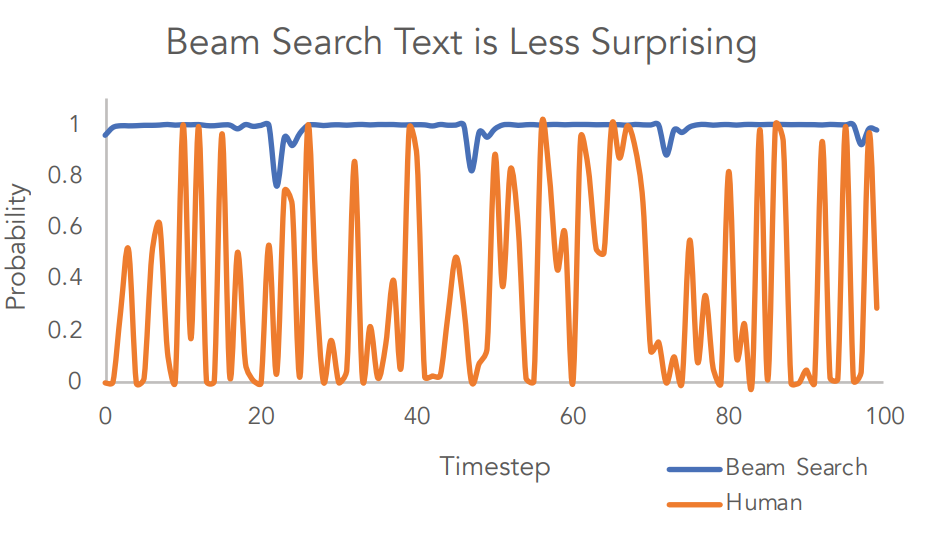

[출처] The Curious Case of Neural Text Degeneration, arXiv:1904.09751 (cs)
https://arxiv.org/abs/1904.09751

### **Basic Sampling**
- 이 방식은 가장 확률이 높은 문장을 찾는 경로를 고집하지 않고, 각 시점에서 조건부 확률 분포에 따라 무작위로 다음 단어를 선택합니다.

$w t​ ∼P(w∣w 1:t−1)$
- 하지만 이렇게 무작위성이 추가되면, 생성된 문장이 일관성이 떨어지고 혼란스러워질 수 있습니다.
- 그래서 무작위성을 제어하기 위해 temperature 파라미터를 도입할 수 있습니다. 이 파라미터는 확률이 높은 단어의 선택 가능성을 높이고, 확률이 낮은 단어는 선택될 가능성을 줄여줍니다.

In [ ]:
# 샘플링을 구현하려면 do_sample = True만 설정하면 됩니다.
# temperature을 설정해주세요.
# 이때 top_k = 0으로 설정해주세요.
sample_output = GPT2.generate(
    input_ids=input_ids,
    do_sample=True,
    temperature=0.7,
    top_k=0,
    max_length=50
)
# output sequences 출력하기
print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens = True))

Output:
----------------------------------------------------------------------------------------------------
I don't know about you, but there's only one thing I want to do after a long day of work: drink some beer. The problem is that I don't have anywhere to drink it.

I know you've heard me mention


💡**temperature 파라미터가 어떤 매커니즘으로  무작위성을 제어하는지**

* temparature가 1보다 작으면 고확률의 단어에 집중한다.
* temparature가 1이면 원래 모델의 확률 분포를 유지하고 표준 softmax와 동일하다.
* temperature가 1보다 크면 분포가 평탄해지면서 저확률 단어를 선택할 가능성이 높아진다. 따라서 창의성을 가질 확률이 높아진다.

### **Top-k Sampling**
- Top-K 샘플링에서는 다음 단어 후보 중 확률이 가장 높은 상위 K개 단어만 선택하고,
전체 probability mass을 이 K개의 단어에만 분배합니다.

> 즉, 확률이 높은 단어의 선택 확률을 높이고, 낮은 단어의 확률을 줄이는 방식이 아니라,아예 확률이 낮은 단어들을 완전히 제거하는 방식!

In [ ]:
# top_k 값을 설정해서, 조건부 확률 분포에서 고려할 상위 단어 개수(K)를 지정해주세요!
sample_output = GPT2.generate(
    input_ids=input_ids,
    do_sample=True,
    top_k=50,
    max_length=50
)
# output sequences 출력하기
print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens = True), '...')

Output:
----------------------------------------------------------------------------------------------------
I don't know about you, but there's only one thing I want to do after a long day of work: Play a game. A nice, relaxing, social game like Tetris. I've already tried a few but every time my partner ...


### **Top-P Sampling(Nucleus Sampling)**
- Top-K 샘플링은 이전의 random sampling보다 더 일관된 텍스트를 생성하는 것으로 보입니다. 하지만 이보다 더나은 방법으로 Top-p sampling이 있습니다.
- Top-P 샘플링은 Top-K와 유사하지만,가장 확률이 높은 상위 K개 단어를 고르는 대신,누적 확률이 P 이상이 되는 최소한의 단어 집합을 선택합니다 그리고 전체 probability mass는 이 단어 집합에 재분배됩니다.


In [ ]:
# top_p 파라미터를 통해 only from 80% most likely words 만  sample 해주세요.
sample_output = GPT2.generate(
    input_ids=input_ids,
    do_sample=True,
    top_p=0.8,
    max_length=50
)
# output sequences 출력하기
print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens = True), '...')

Output:
----------------------------------------------------------------------------------------------------
I don't know about you, but there's only one thing I want to do after a long day of work: go home. I don't want to be bothered by strangers. I don't want to see a lot of people. I want ...


### **Top-K + Top-P sampling**
- 둘을 동시에 사용하면, 확률이 매우 낮은 단어(이상한 단어)가 나올 가능성을 줄이면서도, 선택되는 단어 집합의 크기는 유동적으로 유지할 수 있습니다.

In [ ]:
# top_k와 top_p에 값을 지정하면 되고, temperature 파라미터도 함께 사용할 수 있습니다.
# 아래 코드를 완성해주세요.
# 이때 max_length= 2*MAX_LEN 으로 설정해주세요
sample_outputs = GPT2.generate(
    input_ids=input_ids,
    do_sample=True,
    top_k=50,
    top_p=0.9,
    temperature=0.7,
    max_length=2 * MAX_LEN,
    num_return_sequences=5
)
# output sequences 출력하기
print("Output:\n" + 100 * '-')
for i, sample_output in enumerate(sample_outputs):
    print("{}: {}...".format(i, tokenizer.decode(sample_output, skip_special_tokens = True)))
    print('')

Output:
----------------------------------------------------------------------------------------------------
0: I don't know about you, but there's only one thing I want to do after a long day of work: I want to eat some good food. But I can't afford it. I'm a poor student, and I'm sure I can't afford the food I need to eat. But I want to make sure that if I go back to school, I can afford to eat. So, I've come up with a plan.

I'm going to start a food co-op, and I'm going to give away free food to my fellow students. So, if you're a student in the United States, you can join me. And I'm going to tell...

1: I don't know about you, but there's only one thing I want to do after a long day of work: get out of bed and play some video games.

So I did just that. I got up at 6am on Tuesday morning and hit the road for a few hours. It's not the first time I've done this, but it's definitely the first time I've done it with such a long drive.

It's been a long day. I'm still not sure what I 

💡**Top-k와 Top-p의 방식의 차이에 대해 설명해주세요**

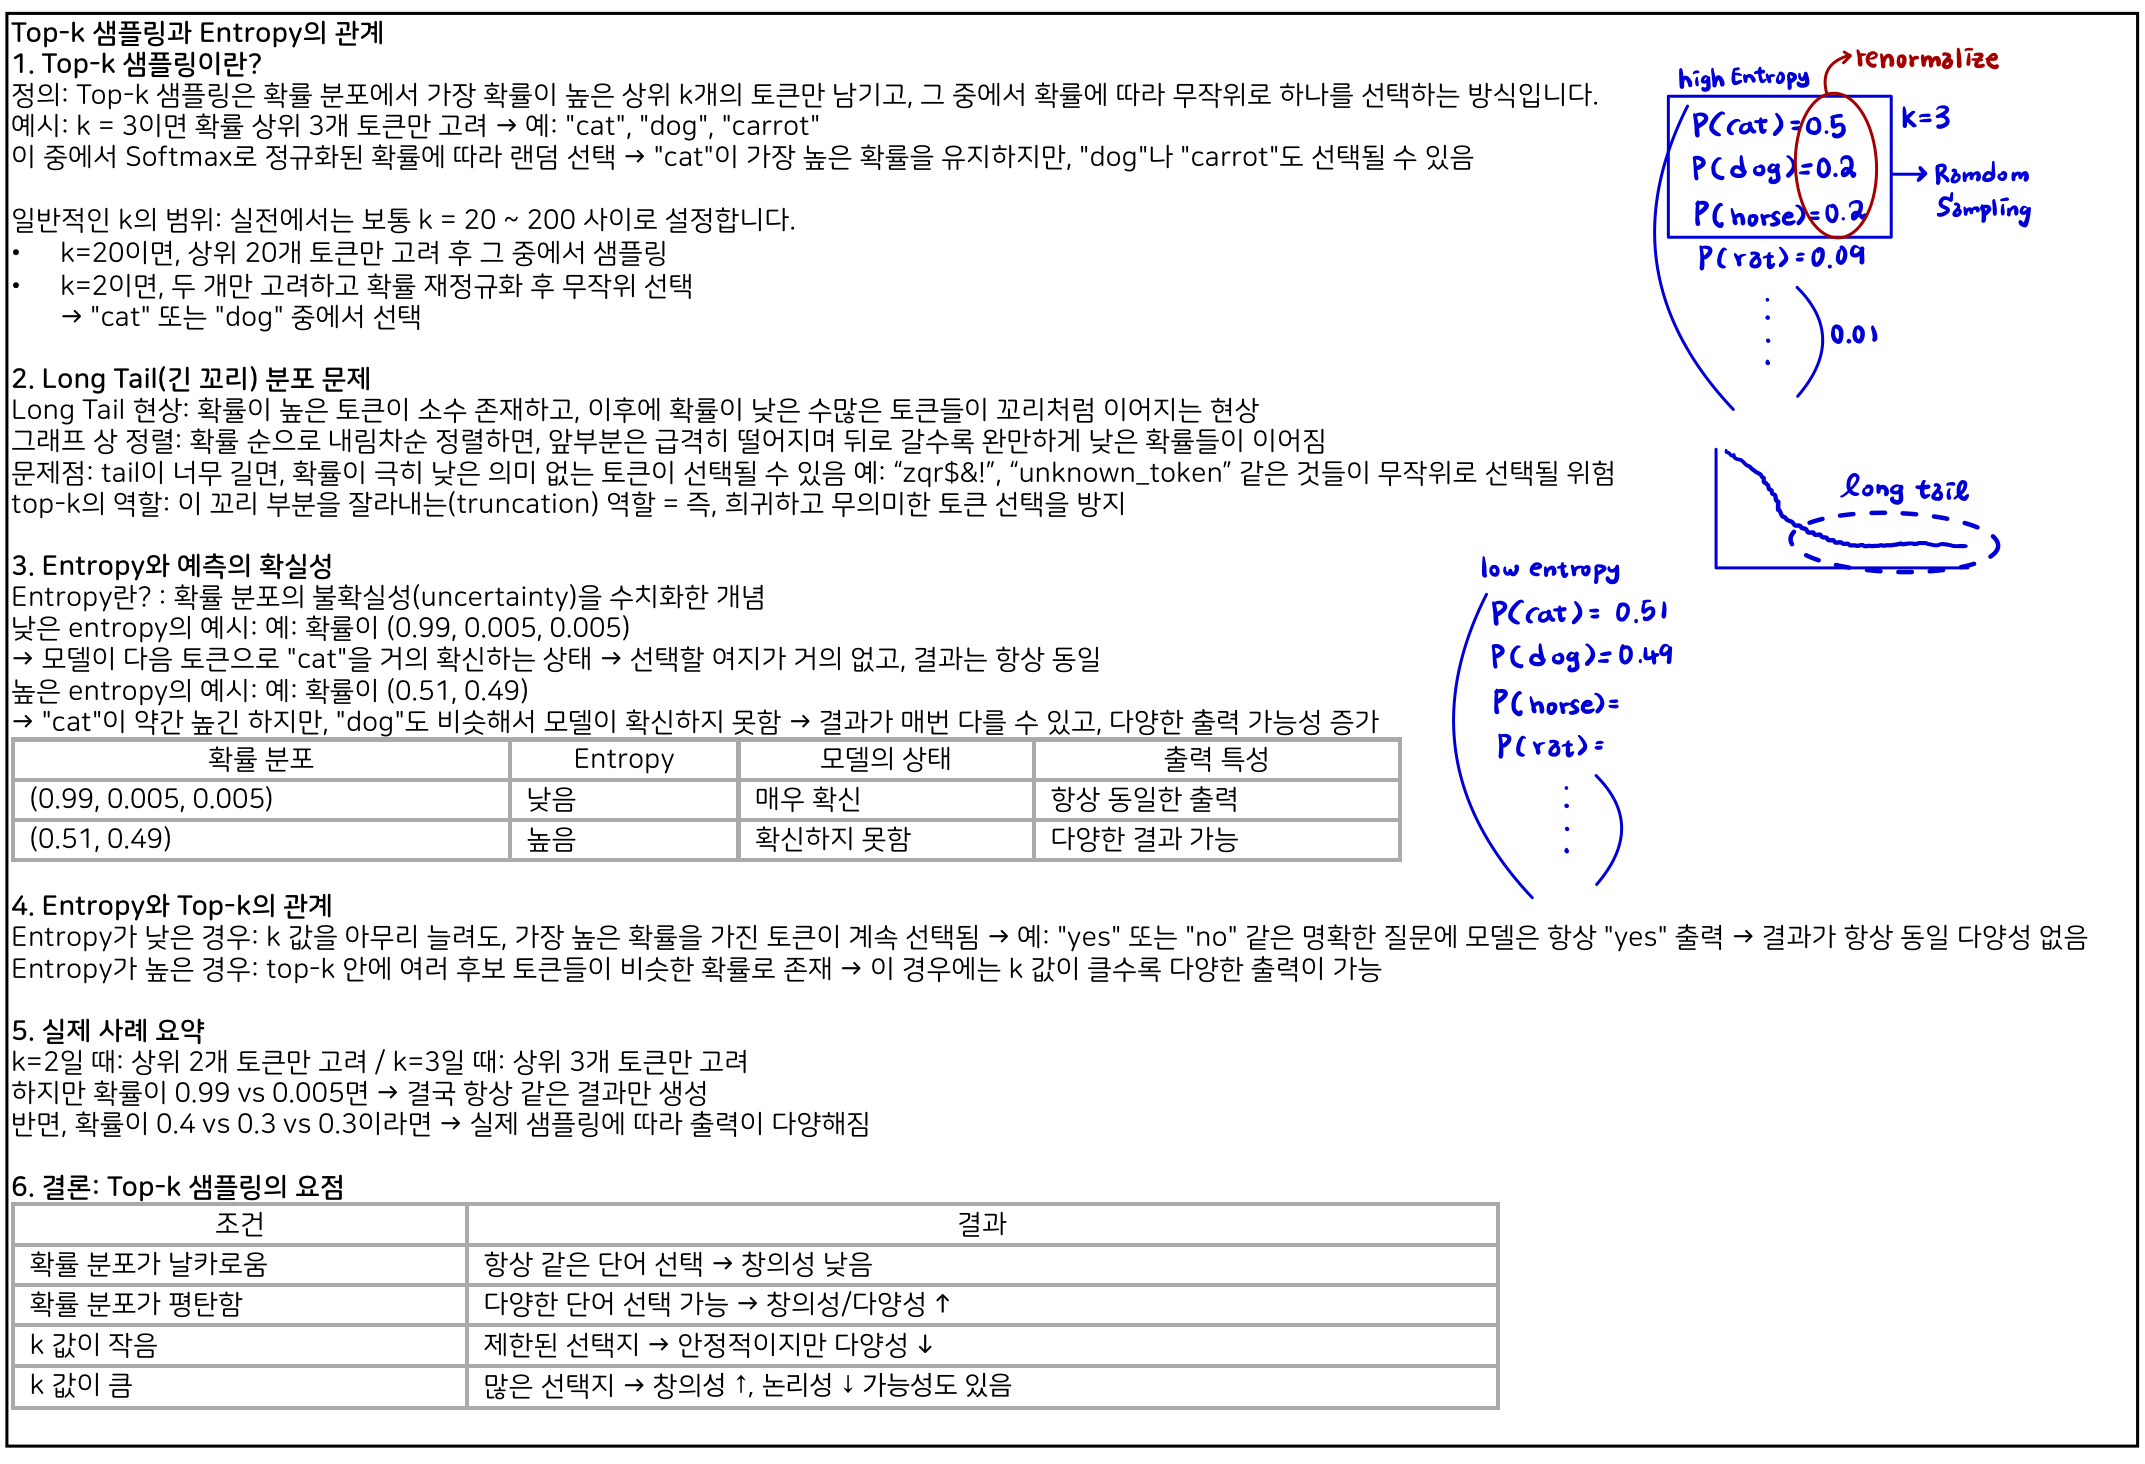

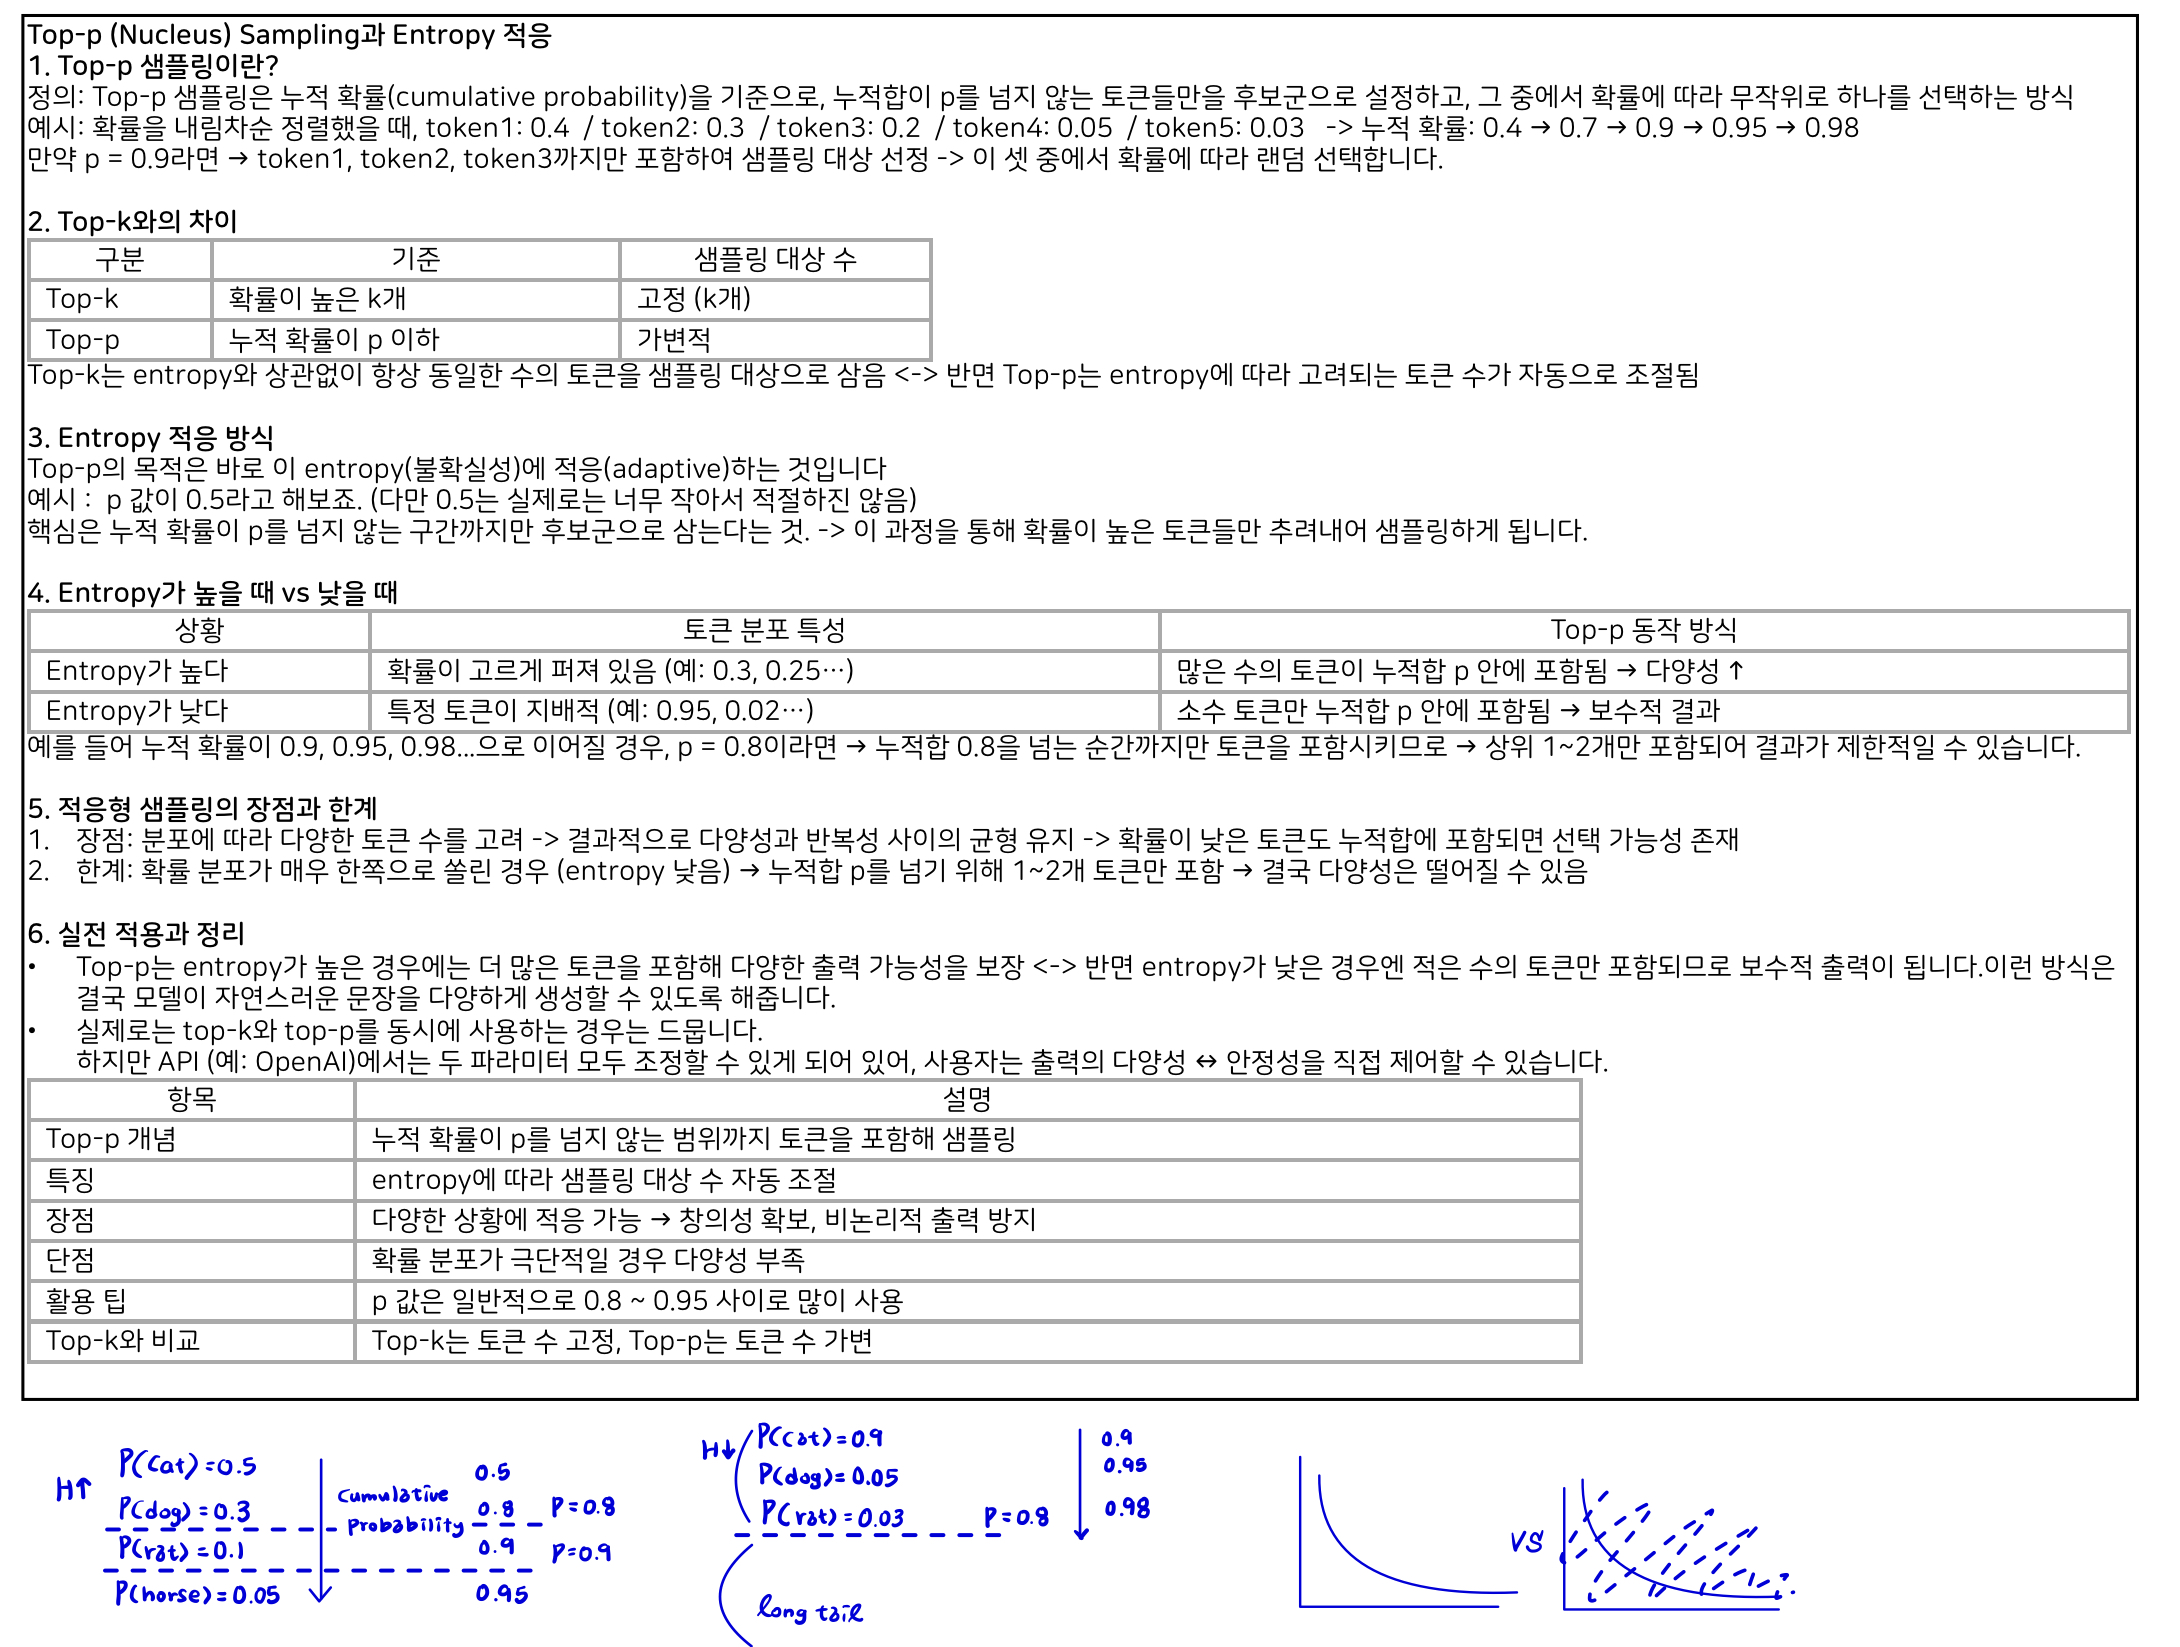